In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import numpy as np
import json
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.figsize": (12, 8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.xmargin": 0,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 1,
    "axes.titlesize": 30,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.size": 22,
    "lines.linewidth": 4,
    "lines.markersize": 10,
    "legend.frameon": True,
})

# mpl.rcParams.update({
#     "figure.figsize": (6, 4),
#     "axes.spines.top": False,
#     "axes.spines.right": False,
#     "axes.facecolor": "#fafafa",
#     "axes.grid": True,
#     "grid.color": "#dddddd",
#     "grid.linestyle": "--",
#     "axes.prop_cycle": mpl.cycler(color=["#4C72B0", "#55A868", "#C44E52",
#                                          "#8172B2", "#CCB974", "#64B5CD"]),
#     "font.size": 11,
#     "axes.labelsize": 12,
#     "axes.titlesize": 14,
#     "legend.frameon": True,
#     "legend.facecolor": "white",
#     "legend.edgecolor": "#dddddd",
#     "lines.linewidth": 2,
# })

from plt_utils import plot, savefig

import os

# task_name, data_name, default_window, default_token_dim = "var-copy", "data_100_5_26", 20, 8 # 20, 24
# task_name, data_name, default_window, default_token_dim = "assoc-recall-mk", "data_100_0_8", 100, 16
# task_name, data_name, default_window, default_token_dim = "decode-recall", "data_100_2_32", 100, 8

# task_name, data_name, default_window, default_token_dim = "assoc-recall-mk", "data_100_0_8", 20, 8
# task_name, data_name, default_window, default_token_dim = "assoc-recall-mk", "data_100_0_8", 20, 16
# task_name, data_name, default_window, default_token_dim = "decode-recall-last", "data_100_2_32", 100, 24
# task_name, data_name, default_window, default_token_dim = "var-copy", "data_100_5_200", 20, 8 # 20, 24
# task_name, data_name, default_window, default_token_dim = "var-copy", "data_100_5_1000", 20, 8 # 20, 24
# task_name, data_name, default_window, default_token_dim = "needle", "data_500_2_100", 100, 8 # 20, 24
# task_name, data_name, default_window, default_token_dim = "needle", "data_100_2_100", 100, 8 # 20, 24
task_name, data_name, default_window, default_token_dim = "needle", "data_100_2_100", 20, 8 # 20, 24

mixed = False

In [63]:
dashed_task_name = '-'.join(task_name.split('_'))

all_losses = {}
all_accs = {}
all_train_accs = {}
all_params = {}

In [64]:
for run_name in os.listdir("results/" + task_name + "/" + data_name):
    if len(run_name.split("_")) != 7: continue

    # if int(run_name.split("_")[4][1:]) > 50: # Filter for large dimension runs
        # continue

    if mixed:
        if run_name.split("_")[0] == "run": continue
    else:
        if run_name.split("_")[0] == "run-mixed": continue

    for run in os.listdir("results/" + task_name + "/" + data_name + "/" + run_name):
        if run.startswith("."):
            continue

        # print("results/" + task_name + "/" + data_name + "/" + run_name + "/" + run)
        # data = torch.load("results/" + task_name + "/" + data_name + "/" + run_name + "/" + run, weights_only=False)
        with open("results/" + task_name + "/" + data_name + "/" + run_name + "/" + run) as infile:
            data = json.load(infile)
        loss = data["final_loss"]
        accs = data["train_accs"]
        print(accs)
        acc = data["final_acc"]
        # args = data["args"]
        params = data["params"]

        if run_name not in all_losses.keys():
            all_losses[run_name] = [loss]
            all_accs[run_name] = [acc[-1]]
            all_params[run_name] = params
            all_train_accs[run_name] = [accs]
        else:
            all_losses[run_name].append(loss)
            all_accs[run_name].append(acc[-1])
            all_train_accs[run_name].append(accs)

for run_name in all_losses.keys():
    all_losses[run_name] = np.array(all_losses[run_name])
    all_accs[run_name] = np.array(all_accs[run_name])
    all_train_accs[run_name] = np.array(all_train_accs[run_name])

[0.0, 0.007936508394777775, 0.0, 0.002016128972172737, 0.0, 0.012827897444367409, 0.08114035427570343, 0.0, 0.04670329764485359, 0.0029761905316263437]
[0.0850694477558136, 0.0, 0.08219178020954132, 0.0, 0.0533333346247673, 0.0, 0.030700424686074257, 0.0, 0.0, 0.0016666667070239782]
[0.04440789297223091, 0.11813186854124069, 0.0, 0.009803921915590763, 0.01666666753590107, 0.0, 0.0, 0.007894736714661121, 0.0, 0.0]
[0.11363636702299118, 0.0, 0.0, 0.0, 0.0013157895300537348, 0.01024590153247118, 0.0, 0.0, 0.0260416679084301, 0.0]
[0.0, 0.023600904271006584, 0.009036144241690636, 0.0, 0.016761362552642822, 0.0, 0.07211538404226303, 0.0, 0.0014367816038429737, 0.0016025641234591603]
[0.0, 0.0, 0.0, 0.1269230842590332, 0.003246753243729472, 0.0, 0.012195121496915817, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.1158854141831398, 0.14880050718784332, 0.1227678582072258, 0.36801114678382874, 0.0, 0.12295082211494446, 0.46090131998062134]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.003968254197388887, 0.0]


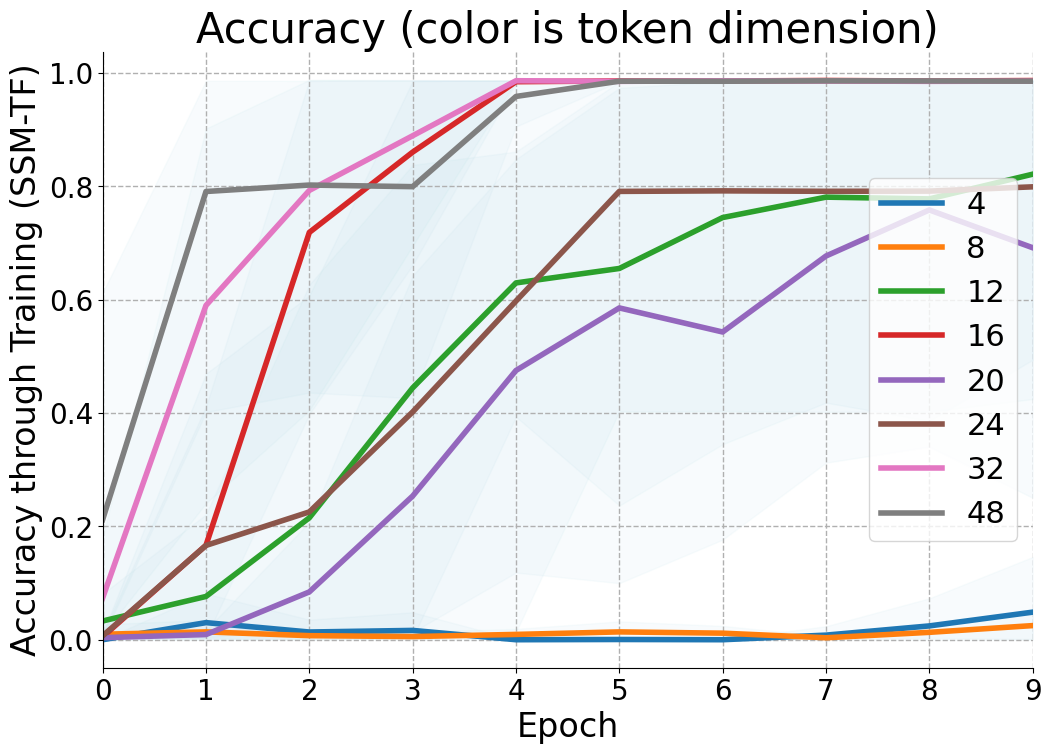

In [65]:
params = {}
params['layer1'] = 'SSM'
params['layer2'] = 'TF'
params['window'] = default_window
params['dim'] = None
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_train_accs, params, 'epochs', 'dim', x_axis='epochs')
plt.ylabel("Accuracy through Training (SSM-TF)")
plt.xlabel("Epoch")
plt.title("Accuracy (color is token dimension)")
savefig(task_name, name)

In [66]:
all_train_accs

{'run_needle_TF-TF_w100_d8_nh1_sd1': array([[0.        , 0.00793651, 0.        , 0.00201613, 0.        ,
         0.0128279 , 0.08114035, 0.        , 0.0467033 , 0.00297619],
        [0.08506945, 0.        , 0.08219178, 0.        , 0.05333333,
         0.        , 0.03070042, 0.        , 0.        , 0.00166667],
        [0.04440789, 0.11813187, 0.        , 0.00980392, 0.01666667,
         0.        , 0.        , 0.00789474, 0.        , 0.        ],
        [0.11363637, 0.        , 0.        , 0.        , 0.00131579,
         0.0102459 , 0.        , 0.        , 0.02604167, 0.        ],
        [0.        , 0.0236009 , 0.00903614, 0.        , 0.01676136,
         0.        , 0.07211538, 0.        , 0.00143678, 0.00160256]]),
 'run_needle_SSM-SSM_w100_d4_nh1_sd1': array([[0.        , 0.        , 0.        , 0.12692308, 0.00324675,
         0.        , 0.01219512, 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.11588541, 0.14880051,
         0.12276786, 

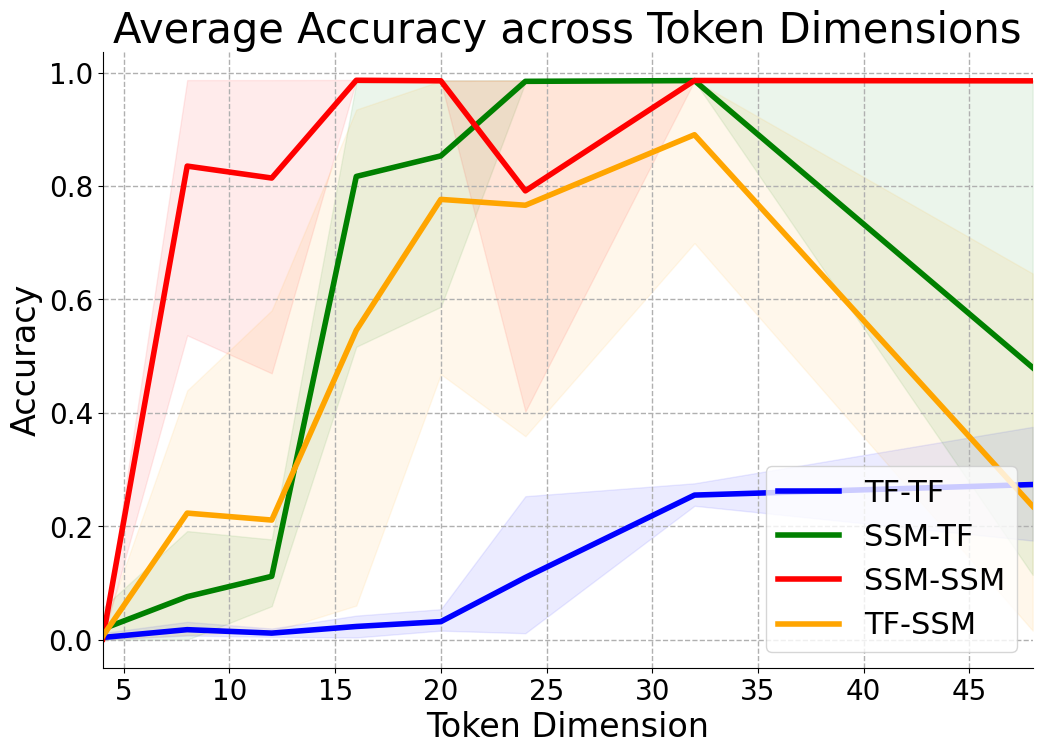

In [67]:
params = {}
params['window'] = default_window
params['dim'] = None
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_accs, params, 'dim', 'layers')
plt.title("Average Accuracy across Token Dimensions")
plt.xlabel("Token Dimension")
plt.ylabel("Accuracy")
savefig(task_name, name)

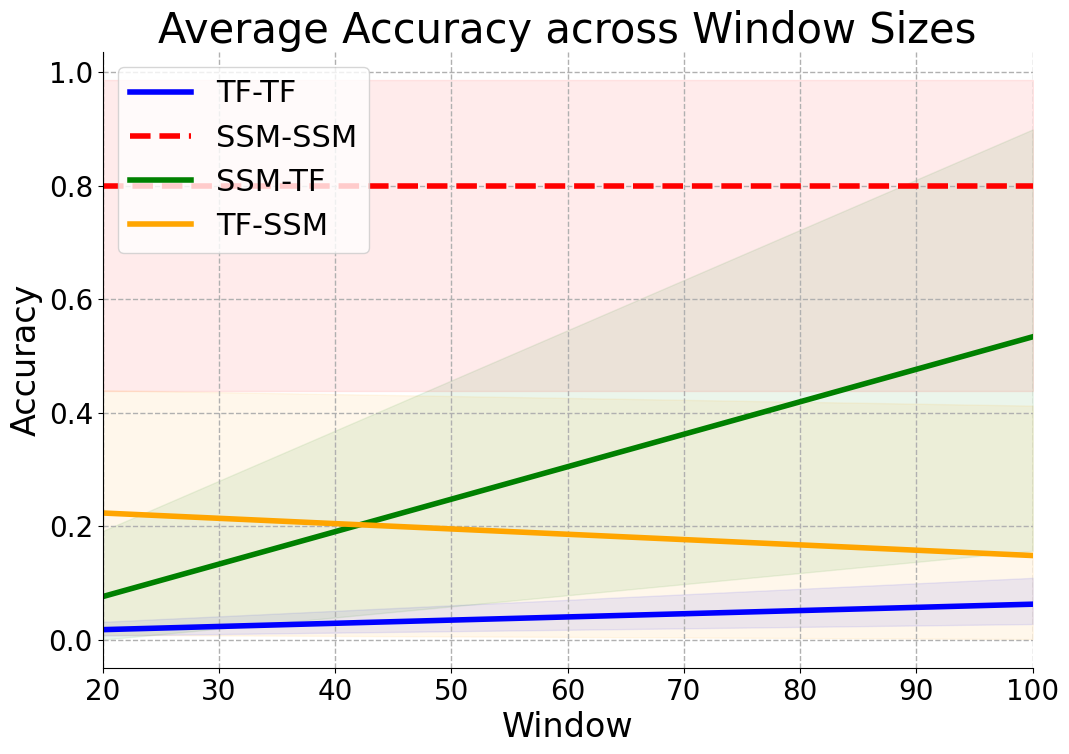

In [68]:
params = {}
params['window'] = None
params['dim'] = default_token_dim
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_accs, params, 'window', 'layers')
plt.title("Average Accuracy across Window Sizes")
plt.xlabel("Window")
plt.ylabel("Accuracy")
savefig(task_name, name)

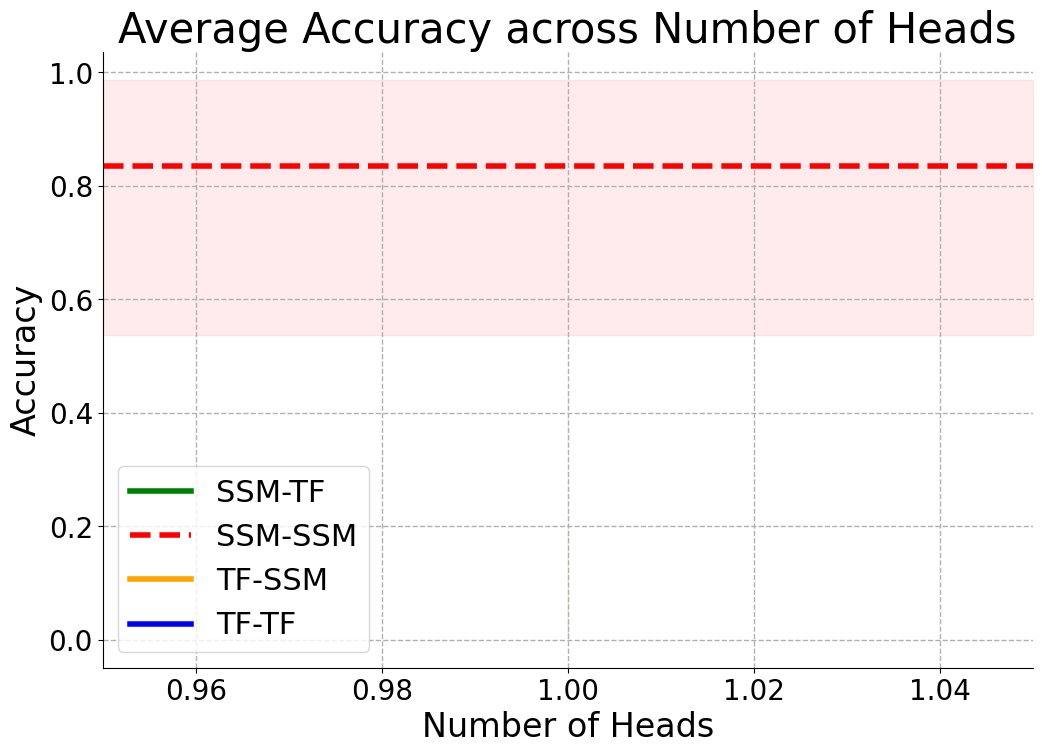

In [69]:
params = {}
params['window'] = default_window
params['dim'] = default_token_dim
params['num_heads'] = None
params['state_dim'] = 1

name = plot(all_accs, params, 'num_heads', 'layers')
plt.title("Average Accuracy across Number of Heads")
plt.xlabel("Number of Heads")
plt.ylabel("Accuracy")
savefig(task_name, name)

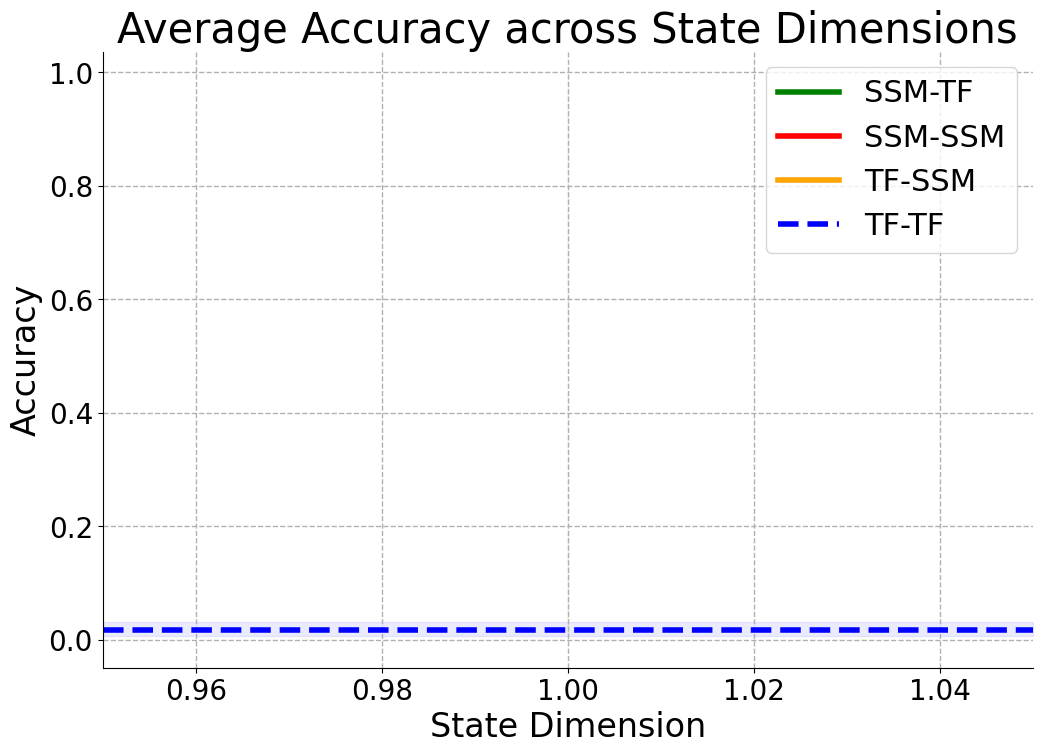

In [70]:
params = {}
params['window'] = default_window
params['dim'] = default_token_dim
params['num_heads'] = 1
params['state_dim'] = None

name = plot(all_accs, params, 'state_dim', 'layers')
plt.title("Average Accuracy across State Dimensions")
plt.xlabel("State Dimension")
plt.ylabel("Accuracy")
savefig(task_name, name)

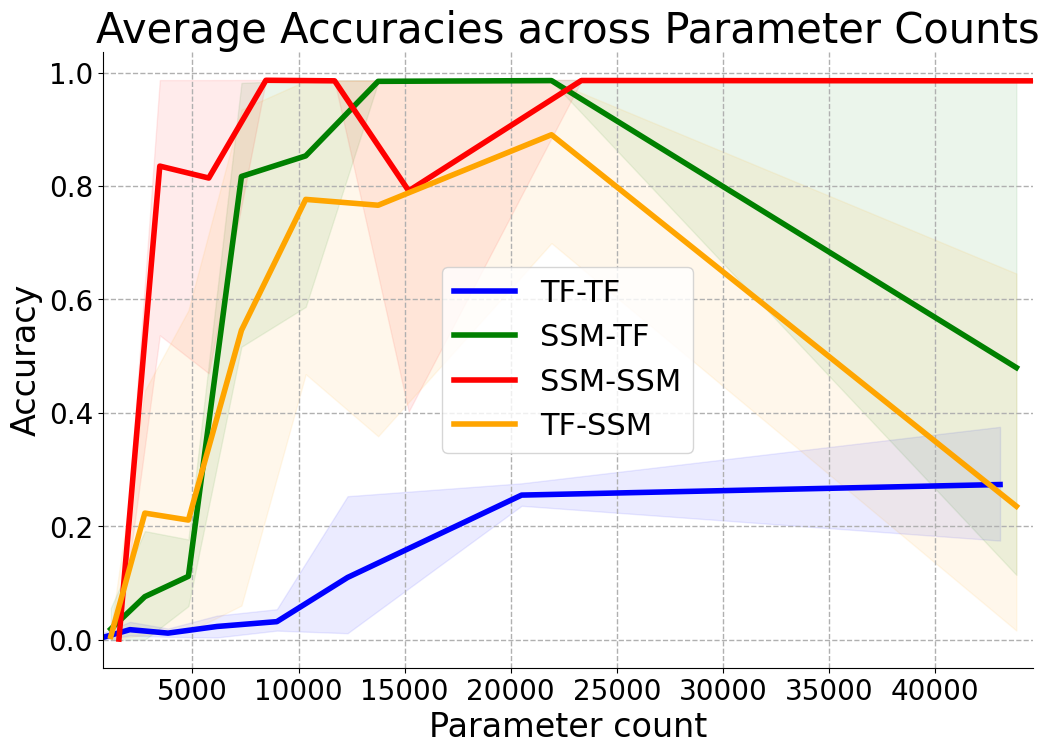

In [71]:
params = {}
params['window'] = default_window
params['dim'] = None
params['num_heads'] = 1
params['state_dim'] = 1

name = plot(all_accs, params, 'dim', 'layers', param_counts=all_params, x_axis='params')
plt.title("Average Accuracies across Parameter Counts")
plt.xlabel("Parameter count")
plt.ylabel("Accuracy")
savefig(task_name, name)

In [72]:
# params = {}
# params['window'] = None
# params['dim'] = 20
# params['num_heads'] = 1
# params['state_dim'] = 1

# name = plot(all_accs, params, 'window', 'layers', param_counts=all_params, x_axis='params')
# plt.title("Average Final Accuracies (dim 20, 1 head, 1 state dimension)")
# plt.xlabel("Parameter count")
# plt.ylabel("Accuracy")
# savefig(task_name, name)

In [73]:
if task_name in ["decode-recall", "decode-recall-last"]:
    params = {}
    params['window'] = None
    # params['dim'] = default_token_dim
    params['dim'] = 192
    params['num_heads'] = 1
    params['state_dim'] = 1

    name = plot(all_accs, params, 'window', 'layers', num_layers=3)
    plt.title("Average Accuracy across Windows")
    plt.xlabel("Window")
    plt.ylabel("Accuracy")
    savefig(task_name, name)
# plt.show()

In [74]:
if task_name in ["decode-recall", "decode-recall-last"]:
    params = {}
    params['window'] = 20
    params['dim'] = None
    params['num_heads'] = 1
    params['state_dim'] = 1

    name = plot(all_accs, params, 'dim', 'layers', num_layers=3)
    plt.title("Average Accuracy across Token Dimensions")
    plt.xlabel("Token Dimension")
    plt.ylabel("Accuracy")
    savefig(task_name, name)
# plt.show()

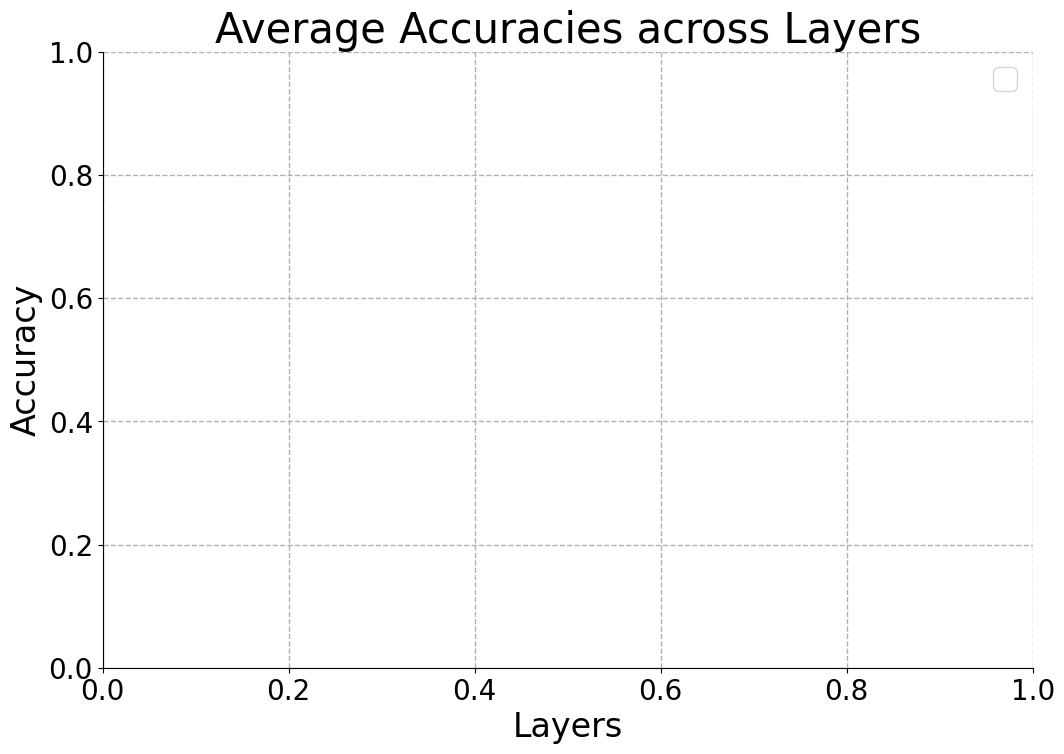

In [75]:
params = {}
params['window'] = default_window
params['dim'] = default_token_dim
params['num_heads'] = 1
params['state_dim'] = 1

# name = plot(all_accs, params, 'dim', 'layers', param_counts=all_params, x_axis='params')
name = plot(all_accs, params, 'layers', 'depths', param_counts=all_params)
plt.title("Average Accuracies across Layers")
plt.xlabel("Layers")
plt.ylabel("Accuracy")
savefig(task_name, name)